In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import os
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from scipy.interpolate import PchipInterpolator, CubicSpline

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)

In [121]:

pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

normed_bias = []
sampled_params = []
sampled_sims = []
# bad = np.load(f"{base_dir}/metadata/badsims_emulated.npy", allow_pickle=True)

fig = plt.figure()

for i in range(10):
    directory = f"{base_dir}/inference/biases/samples_{i}"
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        print(filepath)

        match = pattern.search(filename)
        if match:
            sn = match[0]
            if sn in sampled_sims:
                print(f'resampled')
                continue
            true_params = np.asarray([*df.loc[sn].to_numpy()])#,
                                    #    *whatthetau(df.loc[sn].to_numpy())])

            if not os.path.exists(f"{filepath}/saved_chains.h5"):
                continue
            s, l = utils.load_samples(filepath)
        #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
            chain = s[:,:-1]
            means = np.mean(chain, axis=0)
            stds = np.std(chain, axis=0)

            nbias = (means - true_params[2:]) / stds
            normed_bias.append(nbias)

            sampled_params.append(true_params)
            sampled_sims.append(sn)

# directory = f"{base_dir}/inference/biases/samples1"
# for filename in os.listdir(directory):
#     filepath = os.path.join(directory, filename)
#     print(filepath)

#     match = pattern.search(filename)
#     if match:
#         sn = match[0]
#         if sn in sampled_sims:
#             print('resampled')
#             continue
#         true_params = np.asarray([*df.loc[sn].to_numpy()])#,
#                                 #    *whatthetau(df.loc[sn].to_numpy())])
#         s, l = utils.load_samples(filepath)
#      #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
#         chain = s[:,:-1]
#         means = np.mean(chain, axis=0)
#         stds = np.std(chain, axis=0)

#         nbias = (means - true_params[2:]) / stds
#         normed_bias.append(nbias)

#         sampled_params.append(true_params)
#         sampled_sims.append(sn)
#         # fig = corner.corner(chain, fig=fig)

# directory = f"{base_dir}/inference/biases/samples3"
# for filename in os.listdir(directory):
#     filepath = os.path.join(directory, filename)
#     print(filepath)

#     match = pattern.search(filename)
#     if match:
#         sn = match[0]
#         if sn in sampled_sims:
#             print('resampled')
#             continue
#         true_params = np.asarray([*df.loc[sn].to_numpy()])#,
#                                 #    *whatthetau(df.loc[sn].to_numpy())])
#         s, l = utils.load_samples(filepath)
#      #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
#         chain = s[:,:-1]
#         means = np.mean(chain, axis=0)
#         stds = np.std(chain, axis=0)

#         nbias = (means - true_params[2:]) / stds
#         normed_bias.append(nbias)

#         sampled_params.append(true_params)
#         sampled_sims.append(sn)
#         # fig = corner.corner(chain, fig=fig)

/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10988
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10988...
/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/sampled_pvals.npy
/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu18663
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu18663...
/Users/emcbride/Datasets/LoReLi/inference/biases/samples_1/bias_simu17560
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_1/bias_simu17560...
/Users/emcbride/Datasets/LoReLi/inference/biases/samples_1/bias_simu18924
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_1/bias_simu18924...
/Users/emcbride/Datasets/LoReLi/inference/biases/samples_1/sampled_pvals.npy
/Users/emcbride/Datasets/LoReLi/inference/biases/samples_2/bias_simu16689
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_2/bias

<Figure size 640x480 with 0 Axes>

In [122]:
len(normed_bias)

20

(-4.2, 4.2)

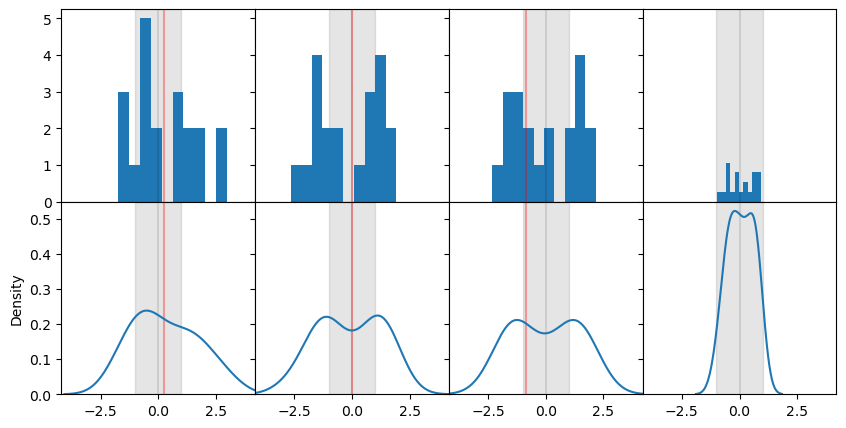

In [126]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

for i in range(3):
    ax[0,i].hist(np.asarray(normed_bias)[:,i], density=False)
    sns.kdeplot(np.asarray(normed_bias)[:,i], ax=ax[1,i])
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.asarray(normed_bias), axis=1), density=True)
sns.kdeplot(np.mean(np.asarray(normed_bias), axis=1), ax=ax[1,3])

ax[0,0].set_xlim(-4.2,4.2)

In [30]:
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

chains_all = []

for survey in survey_labels:
    chains = []
    for setup in setups:
        s, l = utils.load_samples(f"{base_dir}/inference/productionruns2_mechaemu/{survey}/{setup}")
        chains.append(s)

    chains_all.append(chains)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/SO-LAT/noiseless...
Load

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.31193683 8.5233975  0.24940797 0.05290648]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.33095636 8.4658683  0.25531254 0.05327258]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.31785409 8.50016452 0.2614228  0.05352987]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.32806444 8.46742756 0.27622175 0.05419399]


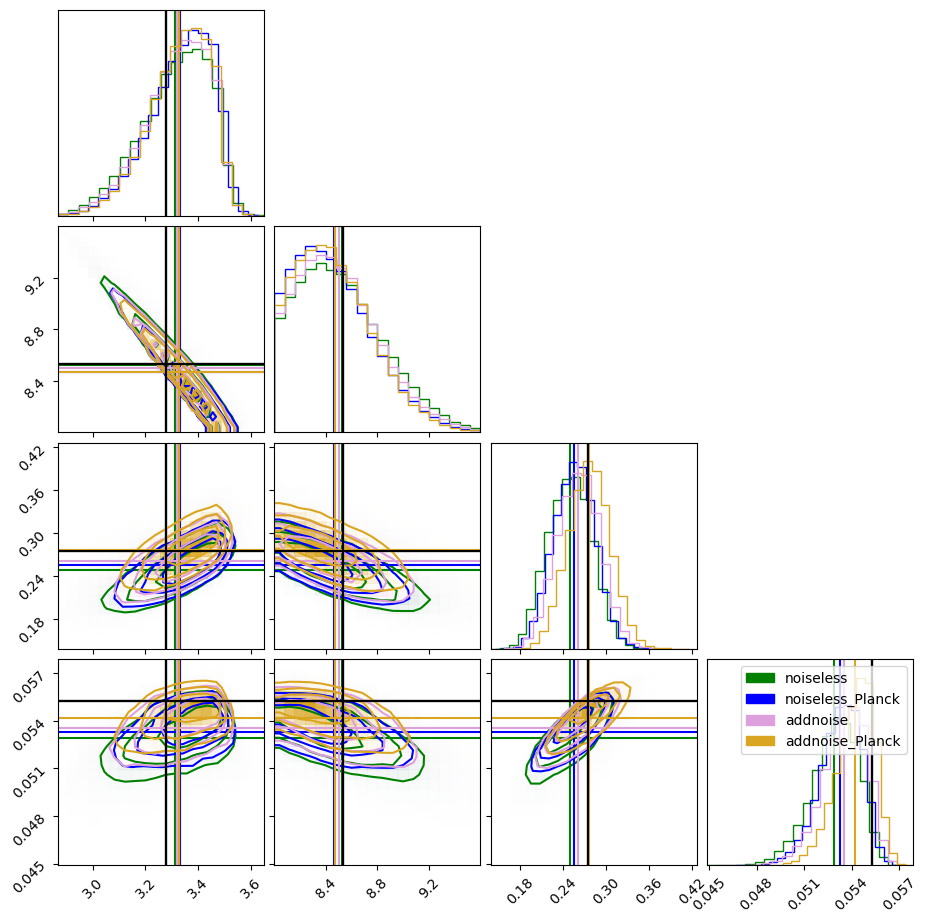

In [31]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 0
chains = chains_all[index]



for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.30671315 8.54457834 0.25739585 0.05306569]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.32027653 8.50416269 0.26592341 0.05350272]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.2926775  8.62572945 0.28424301 0.05351492]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.29809641 8.66470514 0.33214456 0.05434523]


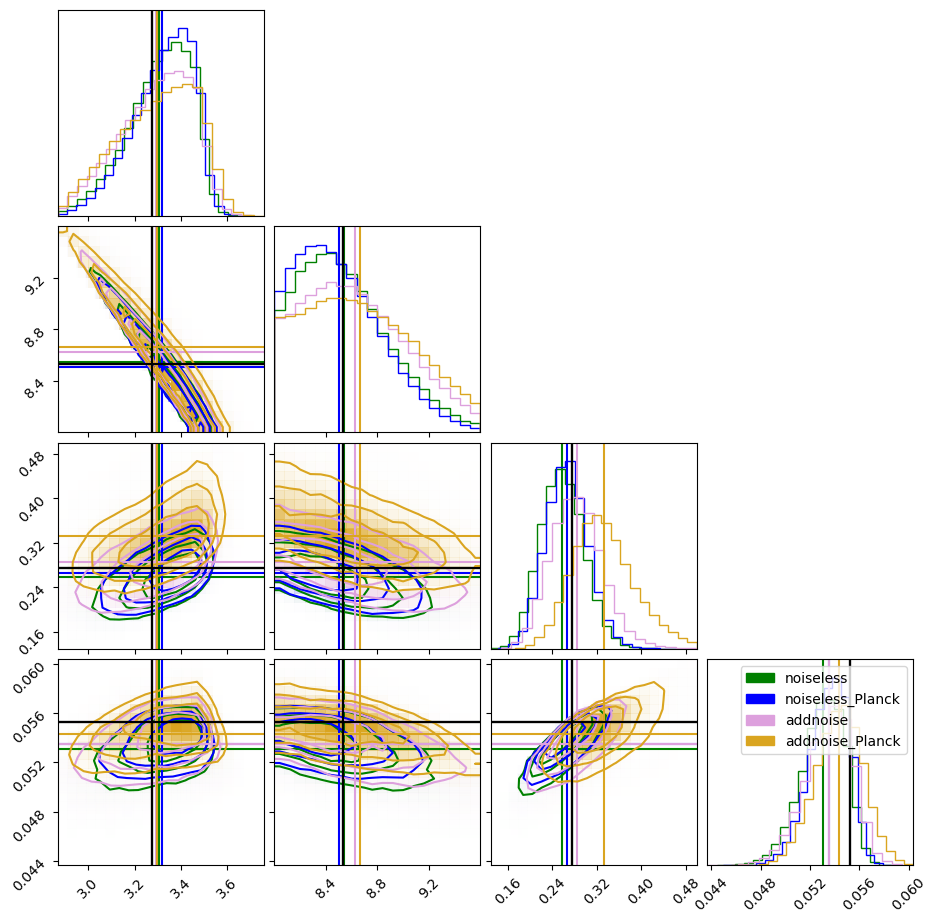

In [32]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 1
chains = chains_all[index]



for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.28483792 8.79343885 0.35932175 0.0536868 ]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.28792343 8.75484512 0.37005541 0.05435944]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.29698738 8.83909317 0.36624335 0.05298294]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[-1.71669877  0.          3.27712767  8.53        0.275       0.05526446]
[3.31421    8.83026642 0.39057559 0.05325167]


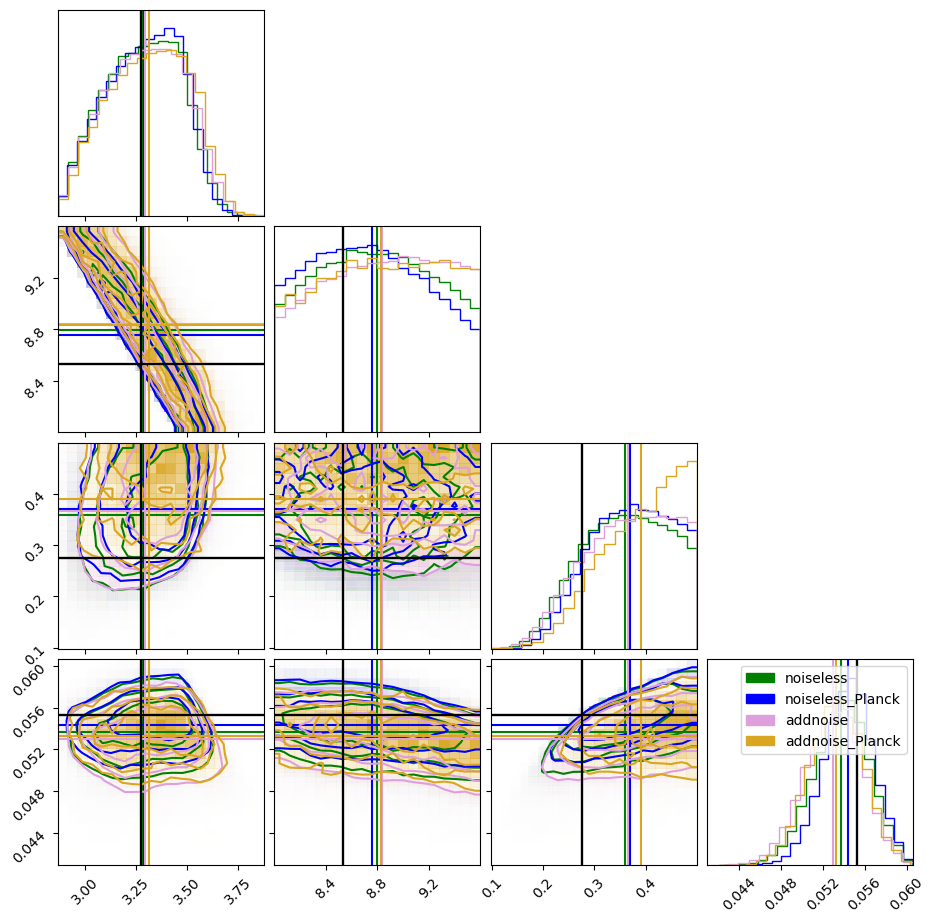

In [33]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 2
chains = chains_all[index]

for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [43]:
from datetime import datetime
import os
import re

directory = f"{base_dir}/metadata/diagnostic_files"
pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

SFR_histories = {}

for filename in os.listdir(directory):
    filepath = os.path.join(directory, filename)
    if os.path.isfile(filepath):
        match = pattern.search(filename)
        if match:
            sn = match[0]
            diagnostic_file = np.genfromtxt(filepath)
            z = diagnostic_file[:,0]
            SFR = diagnostic_file[:,4]

            history = {'z': z,
                       'SFR': SFR}
            
            SFR_histories[sn] = history

In [51]:
SFR_histories[sfrh]['SFR']

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 5.6651e-11, 4.0000e-10, 7.9141e-10, 2.1663e-09,
       5.9143e-09, 1.3297e-08, 2.9815e-08, 6.1431e-08, 1.1660e-07,
       2.0571e-07, 3.5195e-07, 5.8242e-07, 9.2416e-07, 1.4227e-06,
       2.1169e-06, 3.0574e-06, 4.3411e-06, 6.0297e-06, 8.2006e-06,
       1.0937e-05, 1.4346e-05, 1.8526e-05, 2.3592e-05, 2.9657e-05,
       3.6834e-05, 4.5284e-05, 5.5143e-05, 6.6496e-05, 7.9453e-05,
       9.4153e-05, 1.1074e-04, 1.2929e-04, 1.4997e-04, 1.7287e-04,
       1.9812e-04, 2.2580e-04, 2.5600e-04, 2.8879e-04, 3.2426e

(5.0, 20.0)

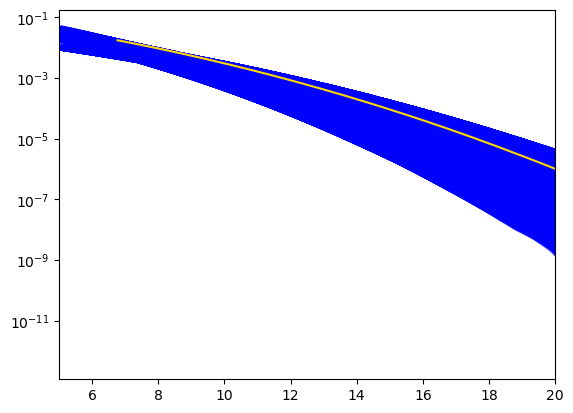

In [76]:
# features = np.

min_z = []
fig, ax = plt.subplots()

for sfrh in SFR_histories:
    if sfrh not in df.index:
        continue
    hist = SFR_histories[sfrh]
    z = hist['z']
    sfr = hist['SFR']

    min_z.append(z.min())

    ax.semilogy(z, sfr, color='blue', alpha=.25)

ax.semilogy(SFR_histories[config.sn]['z'], SFR_histories[config.sn]['SFR'], color='gold', alpha=1.0)

ax.set_xlim(5.0,20.0)


In [64]:
features = np.zeros((len(df), len(df.columns)))
dataset = np.zeros((len(df), ))

np.float64(7.3755)

In [78]:
whatthetau(df.loc[config.sn].to_numpy())[0]

np.float64(0.05526446348700878)

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


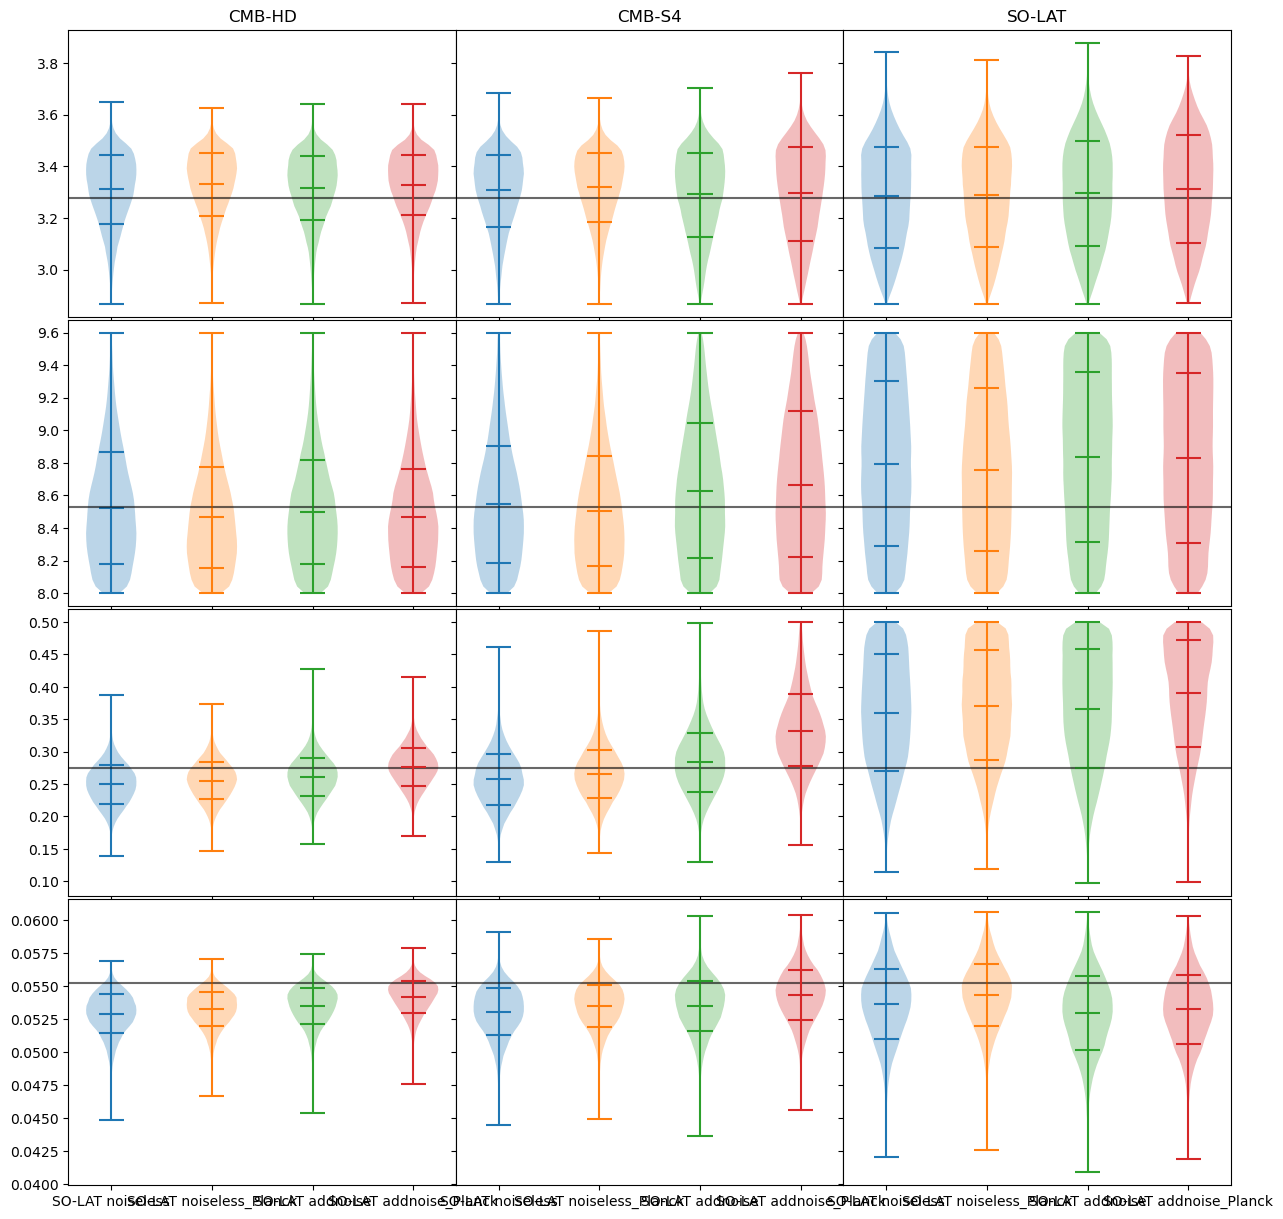

In [72]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(15,15))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

for i, label in enumerate(survey_labels):
    chains = chains_all[i]
    # lps = lps_all[i]
    # datas = datas_all[i]
    # nruns = len(chains)
    for n, setup in enumerate(setups):
        chain = chains[n]
        # lp = lps[n]
        # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin

        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True

        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())

        for ip, p in enumerate(true_params[2:]):
            ax[ip,i].axhline(p, alpha=.2, color='black')
            ax[ip,i].violinplot(chain[:,ip], [n+1], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,i].set_xticks(np.arange(1, len(setups)+1))
    ax[3,i].set_xticklabels([f"{survey} {setup}" for si, setup in enumerate(setups)])
        
    ax[0,i].set_title(f'{label}', fontsize=12)


In [166]:
match = (df.drop(columns='tau') == df.loc[config.sn].drop(labels='tau')).all(axis=1)

# Get matching rows
matching_rows = df[match]
matching_rows

,fX,rHS,tau,Mmin,fesc
sim_n,,,,,
12412,-1.716699,0.0,3.817129,8.53,0.275
10228,-1.716699,0.0,3.709126,8.53,0.275
12958,-1.716699,0.0,3.277128,8.53,0.275
10774,-1.716699,0.0,3.385123,8.53,0.275
11320,-1.716699,0.0,3.601125,8.53,0.275


In [164]:
for sn in df[df['fesc']==.275].index:
    if sn
    if np.abs(df.loc[sn]['tau'] - df['tau'].mean()) < .1:
        print(df.loc[sn])

fX     -3.540608
rHS     0.000000
tau     3.487252
Mmin    8.270000
fesc    0.275000
Name: 10630, dtype: float64
fX     -3.211549
rHS     1.000000
tau     3.487252
Mmin    8.270000
fesc    0.275000
Name: 10647, dtype: float64
fX     -3.716699
rHS     0.800000
tau     3.402743
Mmin    9.330000
fesc    0.275000
Name: 10394, dtype: float64
fX     -2.217012
rHS     0.200000
tau     3.379251
Mmin    8.270000
fesc    0.275000
Name: 12863, dtype: float64
fX     -3.540608
rHS     0.000000
tau     3.379251
Mmin    8.270000
fesc    0.275000
Name: 12814, dtype: float64
fX     -1.716699
rHS     0.800000
tau     3.391006
Mmin    8.800000
fesc    0.275000
Name: 11948, dtype: float64
fX     -2.050181
rHS     0.800000
tau     3.396862
Mmin    9.070000
fesc    0.275000
Name: 11468, dtype: float64
fX     -2.217012
rHS     0.800000
tau     3.504865
Mmin    9.070000
fesc    0.275000
Name: 10370, dtype: float64
fX     -2.050181
rHS     0.200000
tau     3.379251
Mmin    8.270000
fesc    0.275000
Name: 12869

In [156]:
priors

array([[-3.71669877, -1.71669877],
       [ 0.        ,  1.        ],
       [ 2.86858567,  4.02138365],
       [ 8.        ,  9.6       ],
       [ 0.05      ,  0.5       ]])

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns_fittingtruezeus/CMB-HD...
Setup _fittingtrue_abovemeantau has (120000, 4) samples
MAP values are: [3.27858258 8.52652673 0.27528228 0.05526978]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


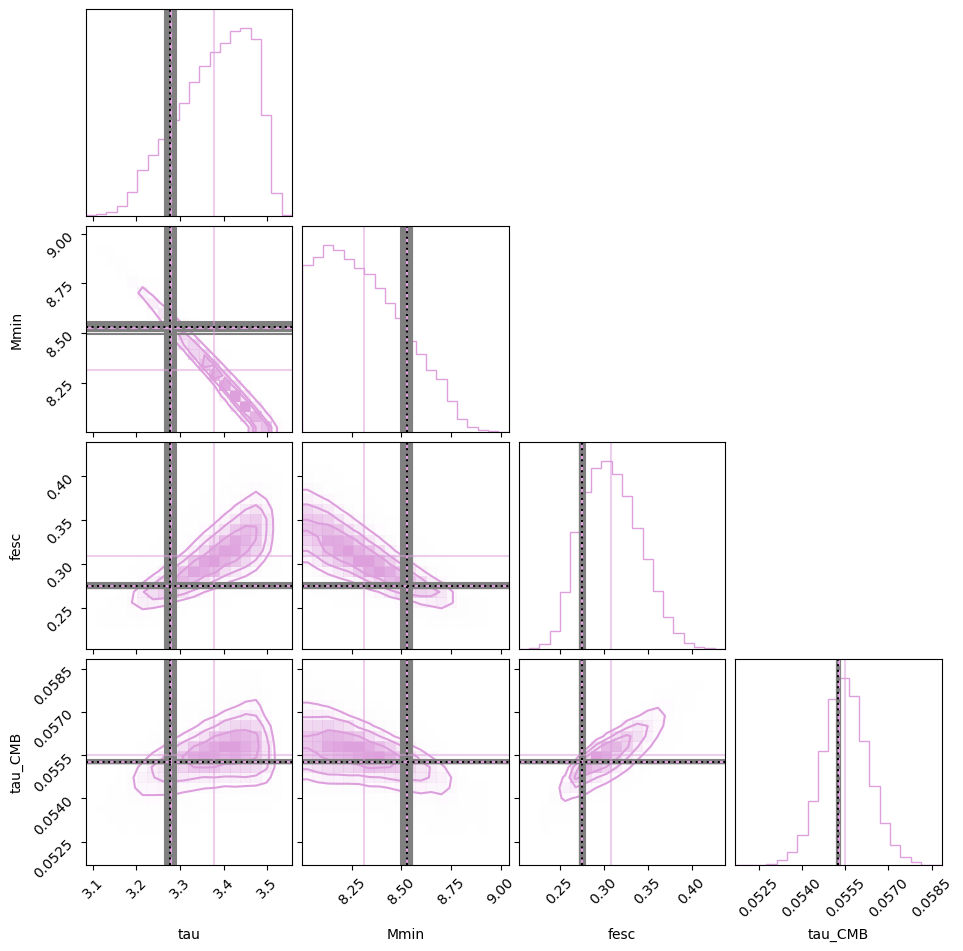

In [175]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

i = 2

chain, lp = utils.load_samples(f"{base_dir}/inference/productionruns_fittingtruezeus/CMB-HD{setup}")
A = False
chain = make_tauchains(chain, A=A)
print(f"Setup {dir[i]} has {chain.shape} samples")
#  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                            hist_kwargs={'density':True}, plot_datapoints=False,
                            levels=[0.393, 0.675, 0.864], fig=fig)

axes = np.array(fig.axes).reshape((ndim, ndim))


plot_kwargs['color'] = 'gray'
# Get indices of values sorted in descending order
top_indices = np.argsort(lp)[-20:][::-1]  # top 20, highest first
for top in top_indices:
    plot_vlines(chain[top], axes, **plot_kwargs)


MAP = chain[np.argmax(lp)]
print(f"MAP values are: {MAP}")
plot_kwargs['color'] = colors[i]
plot_kwargs['ls'] = '-'
plot_kwargs['alpha'] = .5
plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['alpha'] = 1.0
plot_kwargs['ls'] = '--'
plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# # Create custom legend handles
# handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# # Create the legend
# fig.legend(handles=handles, loc='upper right')

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns_fittingtrue2zeus/CMB-HD...
Setup _justpriors has (120000, 4) samples
MAP values are: [3.27819109 8.52677134 0.27527723 0.05527747]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


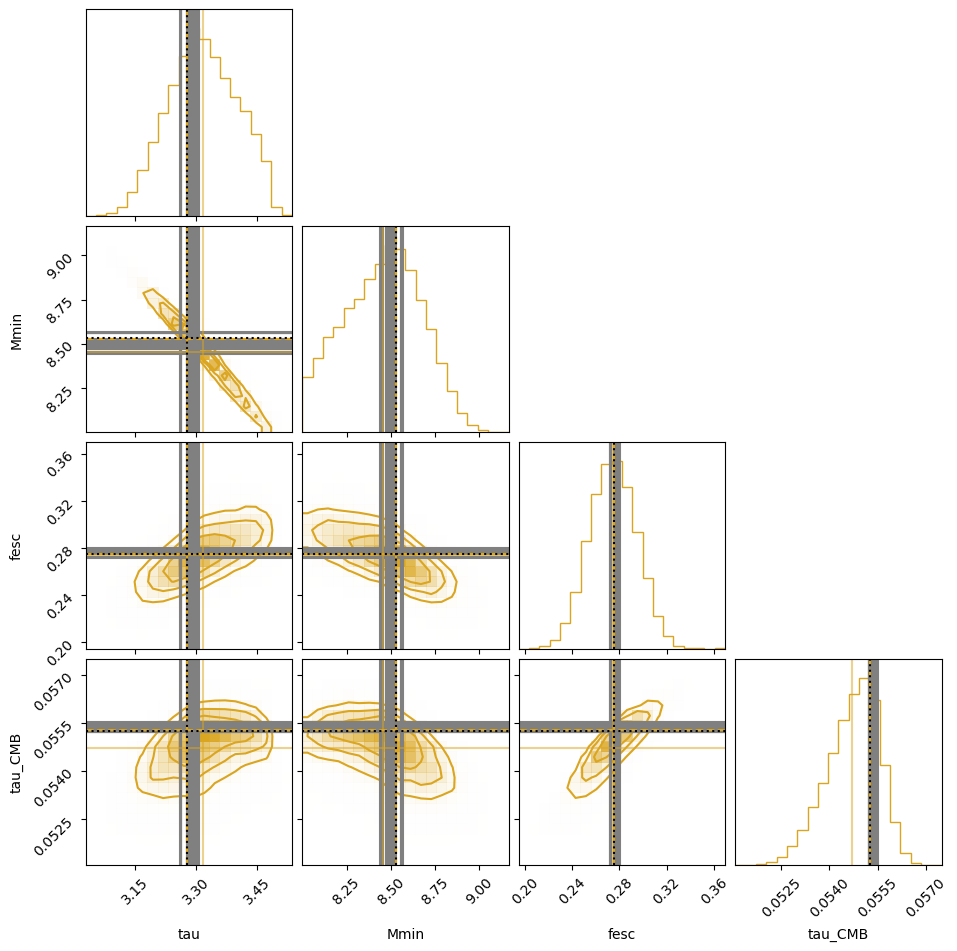

In [174]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])


chain, lp = utils.load_samples(f"{base_dir}/inference/productionruns_fittingtrue2zeus/CMB-HD{setup}")
A = False
chain = make_tauchains(chain, A=A)
print(f"Setup {dir[i]} has {chain.shape} samples")
#  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                            hist_kwargs={'density':True}, plot_datapoints=False,
                            levels=[0.393, 0.675, 0.864], fig=fig)

axes = np.array(fig.axes).reshape((ndim, ndim))


plot_kwargs['color'] = 'gray'
# Get indices of values sorted in descending order
top_indices = np.argsort(lp)[-20:][::-1]  # top 20, highest first
for top in top_indices:
    plot_vlines(chain[top], axes, **plot_kwargs)


MAP = chain[np.argmax(lp)]
print(f"MAP values are: {MAP}")
plot_kwargs['color'] = colors[i]
plot_kwargs['ls'] = '-'
plot_kwargs['alpha'] = .5
plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['alpha'] = 1.0
plot_kwargs['ls'] = '--'
plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# # Create custom legend handles
# handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# # Create the legend
# fig.legend(handles=handles, loc='upper right')

In [40]:
np.vstack([priors, np.array([Planck - 5 * Planck_err, Planck + 5 * Planck_err])])

array([[-3.71669877, -1.71669877],
       [ 0.        ,  1.        ],
       [ 2.86858567,  4.02138365],
       [ 8.        ,  9.6       ],
       [ 0.05      ,  0.5       ],
       [ 0.0276    ,  0.0876    ]])

In [ ]:
# Build the full dataframe
dfs = []
for s in range(S):
    df = pd.DataFrame(chains[s], columns=[f'param_{i+1}' for i in range(P)])
    df['survey'] = survey_names[s]
    dfs.append(df)

# Combine all surveys into one dataframe
df_all = pd.concat(dfs, ignore_index=True)

# Melt to long form for Seaborn
df_long = df_all.melt(id_vars='survey', var_name='parameter', value_name='value')


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


True values are: [3.27712767 8.53       0.275      0.05526446]
Setup 1 has (120000, 4) samples
Setup 1
MAP values are: [3.44751201 8.07542072 0.29965693 0.05559927]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup 3 has (120000, 4) samples
Setup 3
MAP values are: [3.47767284 8.00356885 0.30399725 0.05550107]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


...

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _fittingtrue has (120000, 4) samples
Setup _fittingtrue
MAP values are: [3.25730495 8.57515978 0.27035596 0.05517389]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _simtau has (120000, 4) samples
Setup _simtau
MAP values are: [3.47642594 8.00306389 0.30399343 0.05553868]


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


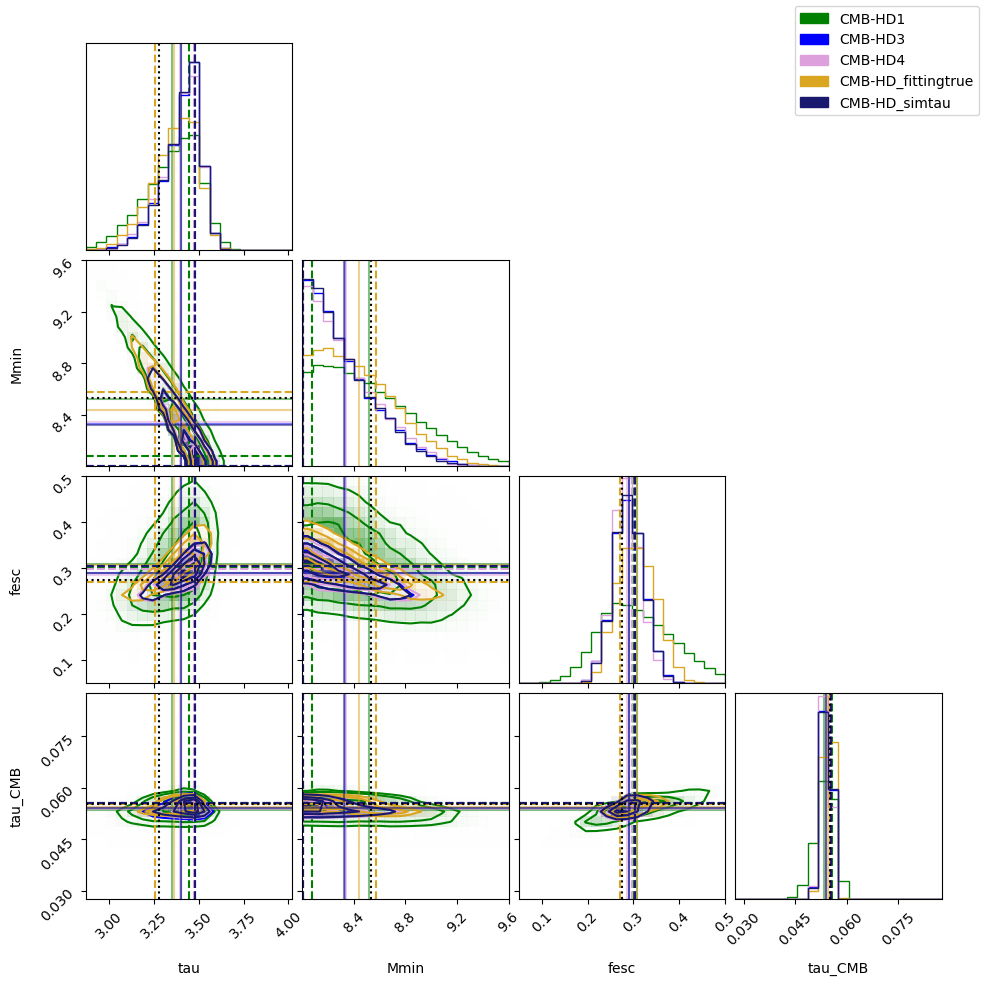

In [44]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10))

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])
print(f"True values are: {truths}")

for i, chain in enumerate(chains):
    lp = lps[i]
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {dir[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                         range=np.vstack([priors, np.array([Planck - 5 * Planck_err, Planck + 5 * Planck_err])])[2:],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    MAP = chain[np.argmax(lp)]
    print(f"==========================")
    print(f"Setup {dir[i]}")
    print(f"==========================")
    print(f"MAP values are: {MAP}")
    plot_kwargs['color'] = colors[i]
    plot_kwargs['ls'] = '-'
    plot_kwargs['alpha'] = .5
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

    plot_kwargs['alpha'] = 1.0
    plot_kwargs['ls'] = '--'
    plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [176]:
mcmcdir = "productionruns3"

pnames = [*df.columns[2:], 'tau_CMB']
survey_list = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setup_list = ['', '_noise', '_Planck', '_noise_Planck']


dfs = []
for survey in survey_list:
    for setup in setup_list:

        s, l = utils.load_samples(f"{base_dir}/inference/{mcmcdir}/{survey}{setup}")
        chain = make_tauchains(s)
        df_chain = pd.DataFrame(chain, columns=pnames)
        df_chain['survey'] = survey

        if 'noise' in setup:
            noise = True
        else:
            noise = False
        if 'Planck' in setup:
            Planck = True
        else:
            Planck = False
        
        df_chain['noise'] = noise
        df_chain['Planck'] = Planck

        dfs.append(df_chain)

df_all = pd.concat(dfs, ignore_index=True)


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3/CMB-HD...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3/CMB-HD_noise...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3/CMB-HD_Planck...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3/CMB-HD_noise_Planck...


...

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3/SO-LAT_Planck...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3/SO-LAT_noise_Planck...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


In [177]:
df_long = df_all.melt(
    id_vars=['survey', 'noise', 'Planck'],
    value_vars=pnames,  # e.g., ['param_1', ..., 'param_5']
    var_name='parameter',
    value_name='value'
)

df_long

,survey,noise,Planck,parameter,value
0,CMB-HD,False,False,tau,3.240380
1,CMB-HD,False,False,tau,3.426594
2,CMB-HD,False,False,tau,3.396769
3,CMB-HD,False,False,tau,3.485192
4,CMB-HD,False,False,tau,3.266138
...,...,...,...,...,...
5759995,SO-LAT,True,True,tau_CMB,0.058406
5759996,SO-LAT,True,True,tau_CMB,0.055434
5759997,SO-LAT,True,True,tau_CMB,0.057395
5759998,SO-LAT,True,True,tau_CMB,0.057981


3.277127671229863
8.53
0.275
0.05526446348700878


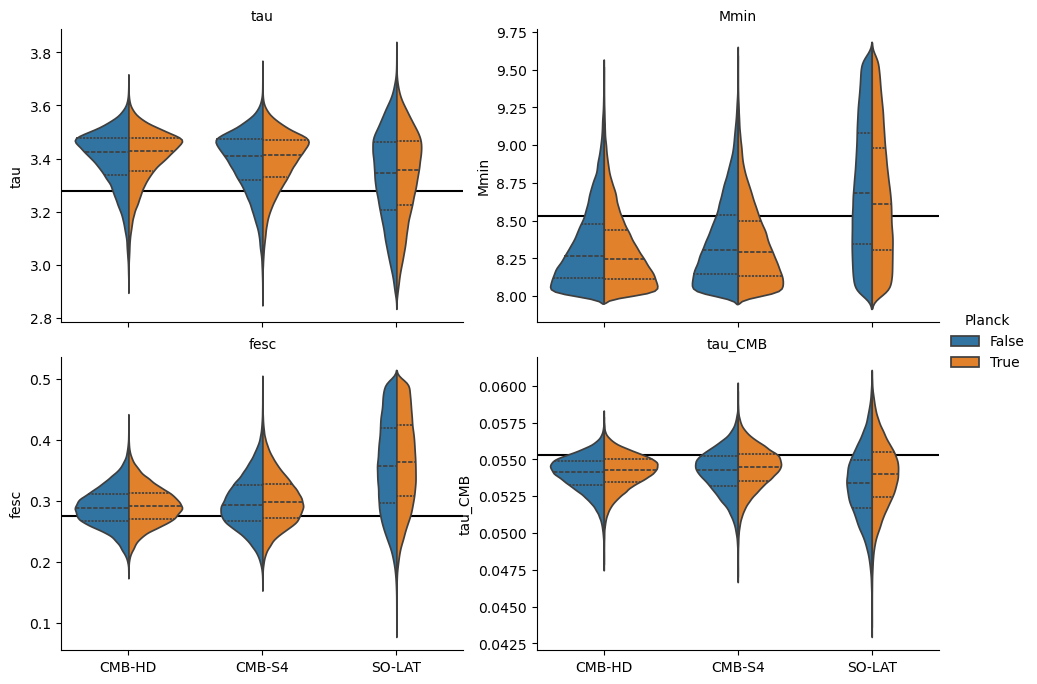

In [178]:
g = sns.catplot(
    data=df_long[df_long['noise'] == False],
    x='survey',             # Group along x-axis by this metadata
    y='value',
    col='parameter',        # One plot per parameter
    kind='violin',
    inner='quart',
    split=True,
    hue='Planck',            # Add another dimension
    dodge=True,
    sharey=False,
    col_wrap=2,
    height=4,
    aspect=1.2
)

for i, ax in enumerate(g.axes.flat):
    print(truths[i])
    ax.axhline(truths[i], color='black', zorder=0)
    ax.set_ylabel(pnames[i])

g.set_xlabels('')

g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.85)
#g.fig.suptitle("Violin Plots of MCMC Parameters by Region and Model")


KeyError: 'tau'

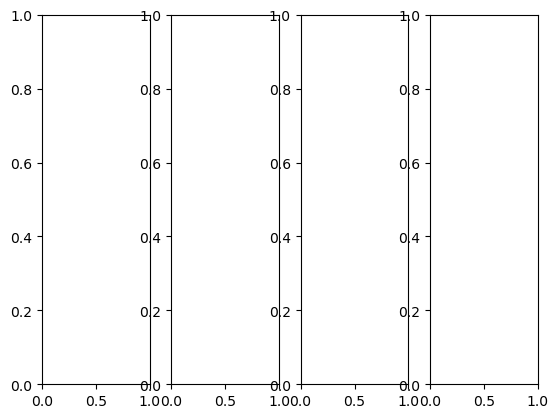

In [38]:
fig, ax = plt.subplots(1,4)

for i, param in enumerate(truths):
    sns.violinplot(data=df_long, x='', ax=ax[i], hue='noise')

CMB-HD data is: [0.68263814 0.64845427 0.6233173  0.56700474 0.49121485 0.44225413
 0.41007305 0.36637456 0.34329635 0.30634866 0.30406491 0.23246124
 0.20777116 0.19410263]
CMB-HD data is: [0.70437825 0.63278039 0.6321156  0.58624299 0.49154632 0.44082307
 0.41373904 0.3619274  0.34676307 0.30168527 0.32368212 0.22399757
 0.21125182 0.21377196]
CMB-S4 data is: [0.64406442 0.63448482 0.60593675 0.55050097 0.51621802 0.44042283
 0.40157314 0.33479246 0.34408153 0.31379556 0.23771971 0.29623046
 0.18493555 0.21063406]
CMB-S4 data is: [0.62723081 0.6048415  0.59735451 0.55323544 0.54155265 0.43716048
 0.39673921 0.2987632  0.34833344 0.31657909 0.19099171 0.351536
 0.1655806  0.24683482]
SO-LAT data is: [ 0.69261157  0.69873034  0.65681686  0.61214131  0.57020073  0.46895347
  0.46220616  0.62937407  0.43057151  0.43984677 -1.00952324  1.8744581
  4.63089235 27.81090711]
SO-LAT data is: [ 0.72432511  0.73333253  0.69911473  0.67651612  0.64951807  0.49422176
  0.51800526  0.88792642  0.52

(0.0, 1.0)

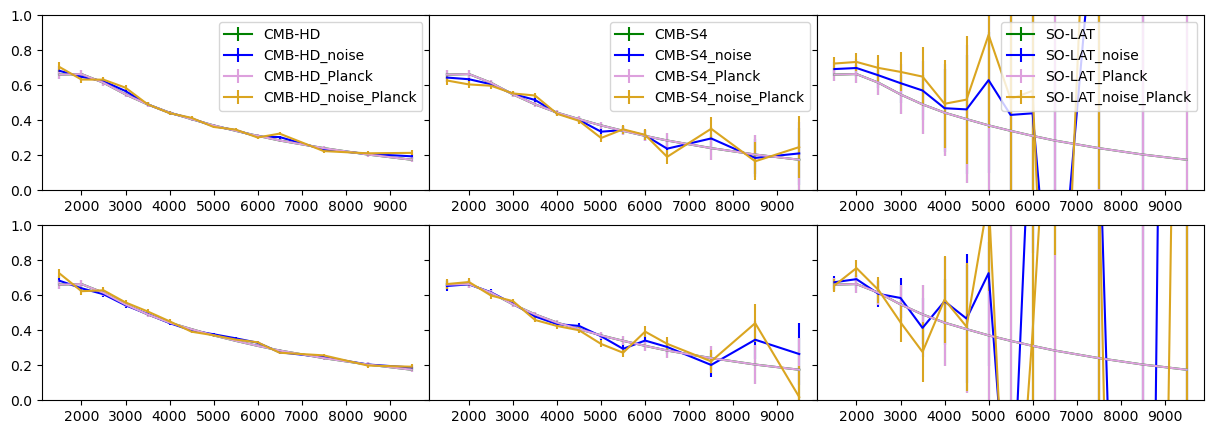

In [66]:
fig, ax = plt.subplots(2, len(survey_list), sharey=True, figsize=(15,5))
fig.subplots_adjust(wspace=0.0)

for i, experiment in enumerate(survey_list):

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=False)
    err_obs =np.sqrt(np.diag(err_cov))

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=True)
    err_fit =np.sqrt(np.diag(err_cov))
  #  print(f"err={err}")

    for j, setup in enumerate(setup_list):
     #   print(f"{experiment}{setup}")

        data = np.load(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}/data.npz", allow_pickle=True)
        data2 = np.load(f"{base_dir}/inference/productionruns1/{experiment}{setup}/data.npz", allow_pickle=True)

        if 'noise' in setup:
            print(f"{experiment} data is: {data['datapoints']}")

        # print(f"Old error: {data2['err']}")
        # print(f"New error: {data['err']}")
        # print()
        # print(f"New / Old: {data['err'] / data2['err']}")
        # print()

        ax[0,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
                            yerr=err_fit[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
        ax[1,i].errorbar(ells[indices][data2['lmask']], data2['datapoints'],
                            yerr=err_fit[data2['lmask']], color=colors[j], label=f"{experiment}{setup}")

        # if 'noise' not in setup:
        #     ax[0,i].plot(ells[indices][data['lmask']], data['datapoints'], color=colors[j], label=f"{experiment}{setup}")
        #     ax[1,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
        #                     yerr=err_fit[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
        # else:
        #     ax[0,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
        #                     yerr=err_obs[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
            
        ax[0,i].legend()

ax[0,0].set_ylim(0.0, 1.0)

array([0.36754306, 0.48524992, 0.80102255, 0.88422853, 0.94129105,
       0.97991099, 0.99243262, 0.99573795, 0.99769618, 0.99929123,
       0.99963458, 1.00008312, 0.99995301, 1.00121924])

In [33]:
truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])
truths

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


array([3.27712767, 8.53      , 0.275     , 0.05526446])

In [193]:
truths

array([3.27712767, 8.53      , 0.275     , 0.05526446])

In [13]:
def playtheviolons(chains):
    psamples = np.zeros((len(chains), chains[0].shape[0], len(truths)))

    for ic, chain in enumerate(chains):
        print(f"Now on chain {ic} which looks like {chain.shape}")
        chain = make_tauchains(chain, A=True)
        for ip in range(len(truths)):
            psamples[ic,:,ip] = chain[:,ip]

    return psamples

allparamchains = []
# Loop over subfigures and add a simple plot in each
for chains in [chains_CMBHD, chains_S4, chains_SOLAT]:
    print(chains[0].shape)
    param_chains = playtheviolons(chains)
    print(param_chains.shape)
    allparamchains.append(param_chains)

(120000, 4)
Now on chain 0 which looks like (120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Now on chain 1 which looks like (120000, 4)
Now on chain 2 which looks like (120000, 4)
Now on chain 3 which looks like (120000, 4)
(4, 120000, 4)
(120000, 4)
Now on chain 0 which looks like (120000, 4)
Now on chain 1 which looks like (120000, 4)
Now on chain 2 which looks like (120000, 4)
Now on chain 3 which looks like (120000, 4)
(4, 120000, 4)
(120000, 4)
Now on chain 0 which looks like (120000, 4)
Now on chain 1 which looks like (120000, 4)
Now on chain 2 which looks like (120000, 4)
Now on chain 3 which looks like (120000, 4)
(4, 120000, 4)


In [72]:
prior_draw = draws(int(120000))
prior_draw.shape

(120000, 5)

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup  has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _noise has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _Planck has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _noise_Planck has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


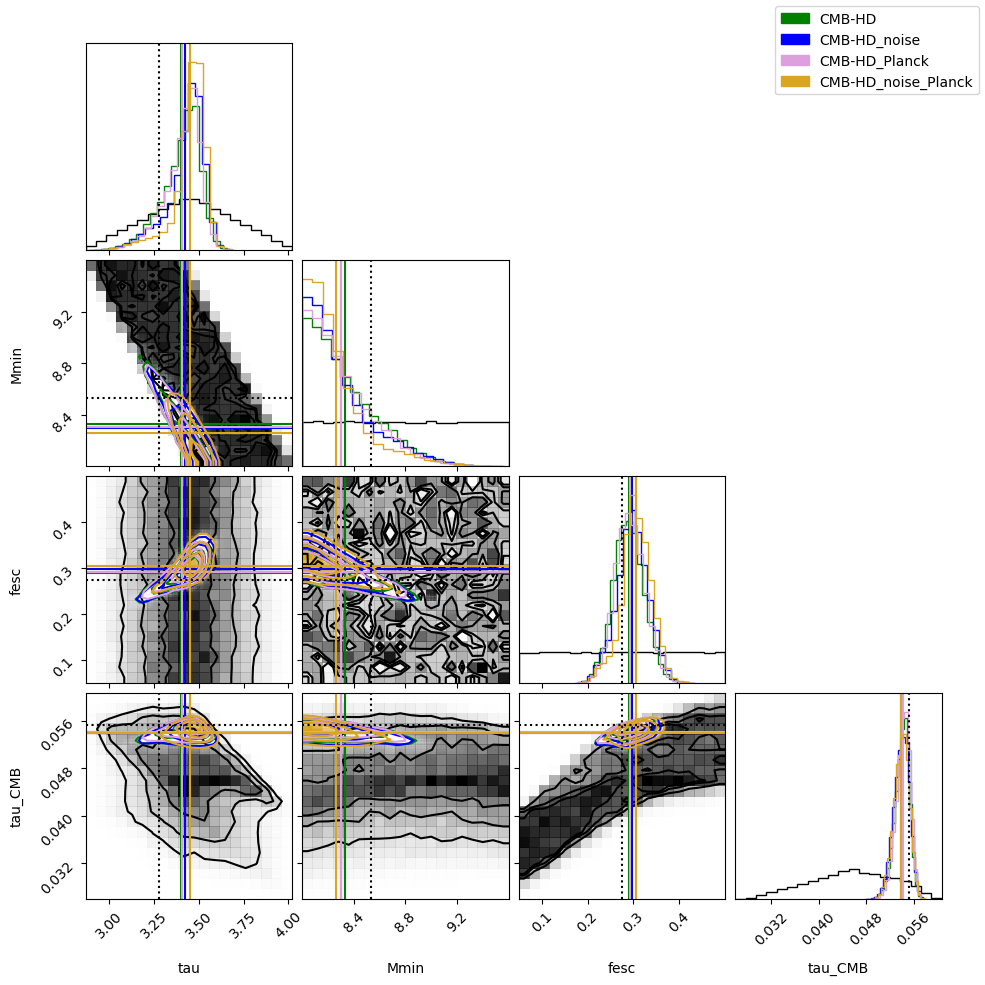

In [73]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

prior_chain = make_tauchains(prior_draw[:,2:], A=False)
fig = corner.corner(prior_chain, color='black', labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)

for i, chain in enumerate(chains_CMBHD):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)



plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

prior_chain = make_tauchains(prior_draw, A=False)
fig = corner.corner(prior_chain, color='black', labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)

for i, chain in enumerate(chains_CMBHD):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)



plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [137]:
print("CMB-HD no Planck")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chains_CMBHD[0], A=A), axis=0) - truths) / np.std(make_tauchains(chains_CMBHD[0], A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

CMB-HD no Planck
mean value of tau is 0.486 sigma away from true value...
mean value of Mmin is -0.027 sigma away from true value...
mean value of fesc is 0.436 sigma away from true value...
mean value of tau is -0.620 sigma away from true value...


In [138]:
print("CMB-HD and Planck")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chains_CMBHD[2], A=A), axis=0) - truths) / np.std(make_tauchains(chains_CMBHD[2], A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

CMB-HD and Planck
mean value of tau is 0.588 sigma away from true value...
mean value of Mmin is -0.146 sigma away from true value...
mean value of fesc is 0.718 sigma away from true value...
mean value of tau is -0.391 sigma away from true value...


In [139]:
print("CMB-HD and Planck + noise")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chain, A=A), axis=0) - truths) / np.std(make_tauchains(chain, A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

CMB-HD and Planck + noise
mean value of tau is 0.605 sigma away from true value...
mean value of Mmin is -0.191 sigma away from true value...
mean value of fesc is 0.728 sigma away from true value...
mean value of tau is -0.319 sigma away from true value...


In [ ]:
for i, chain in enumerate(chains_S4):
    chi2_contribution(chain.mean(axis=0), model, data, err, truths=None)

In [150]:
theta = fill(s.mean(axis=0), data['truths'].item(), df.columns[2:])
theta

array([[-1.71669877,  0.        ,  3.35028591,  8.52041739,  0.30795319]])

In [163]:
s[::1000].shape

(120, 4)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-HD...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-HD_noise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-HD_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-HD_noise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-S4...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-S4_noise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-S4_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/CMB-S4_noise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/SO-LAT...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns1/SO-LAT_noise...
Loading samples from /Users/emcbride/Datasets/LoReLi

(0.0, 4.0)

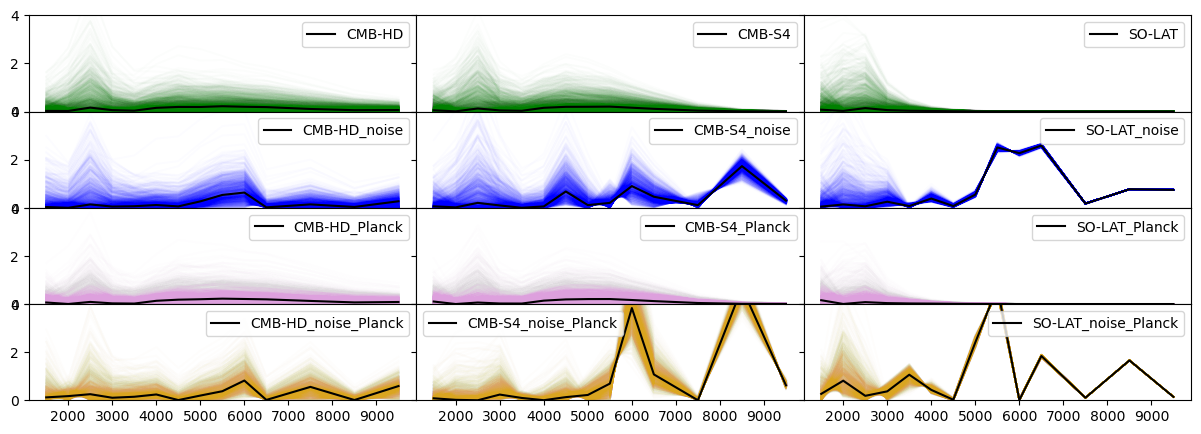

In [170]:
fig, ax = plt.subplots(4, len(survey_list), sharex=True, sharey=True, figsize=(15,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, experiment in enumerate(survey_list):

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=False)
    err_obs =np.sqrt(np.diag(err_cov))

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=True)
    err_fit =np.sqrt(np.diag(err_cov))
  #  print(f"err={err}")

    for j, setup in enumerate(setup_list):
     #   print(f"{experiment}{setup}")

      data = np.load(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}/data.npz", allow_pickle=True)
      s, l = utils.load_samples(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}")
      chi2_all = chi2_contribution(s[::100], lambda params: emulator.kemu(params, **emu)[:,data['lmask']],
                                data['datapoints'],
                                data['err'], truths=data['truths'].item())
      chi2 = chi2_contribution(s.mean(axis=0), lambda params: emulator.kemu(params, **emu)[:,data['lmask']],
                                data['datapoints'],
                                data['err'], truths=data['truths'].item())
      
      ax[j,i].plot(data['ells'], chi2_all.T, color=colors[j], alpha=.01)
      ax[j,i].plot(data['ells'], chi2.flatten(), color='black', label=f'{experiment}{setup}')
      ax[j,i].legend()

ax[0,0].set_ylim(0.0, 4.0)

In [ ]:
s.mean(axis=0), lambda params: emulator.kemu(params, **emu)[data['lmask']],
                                  data['datapoints'],
                                  data['err'], truths=data['truths'].item()

In [148]:
# Build the full dataframe

survey_names = ['Survey A', 'Survey B', 'Survey C']

dfs = []
for s in range(S):
    df = pd.DataFrame(chains[s], columns=[f'param_{i+1}' for i in range(P)])
    df['survey'] = survey_names[s]
    dfs.append(df)

# Combine all surveys into one dataframe
df_all = pd.concat(dfs, ignore_index=True)

# Melt to long form for Seaborn
df_long = df_all.melt(id_vars='survey', var_name='parameter', value_name='value')


{'fX': -1.7166987712964503,
 'rHS': 0.0,
 'tau': 3.277127671229863,
 'Mmin': 8.53,
 'fesc': 0.275}

Setup  has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _noise has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _Planck has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _noise_Planck has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


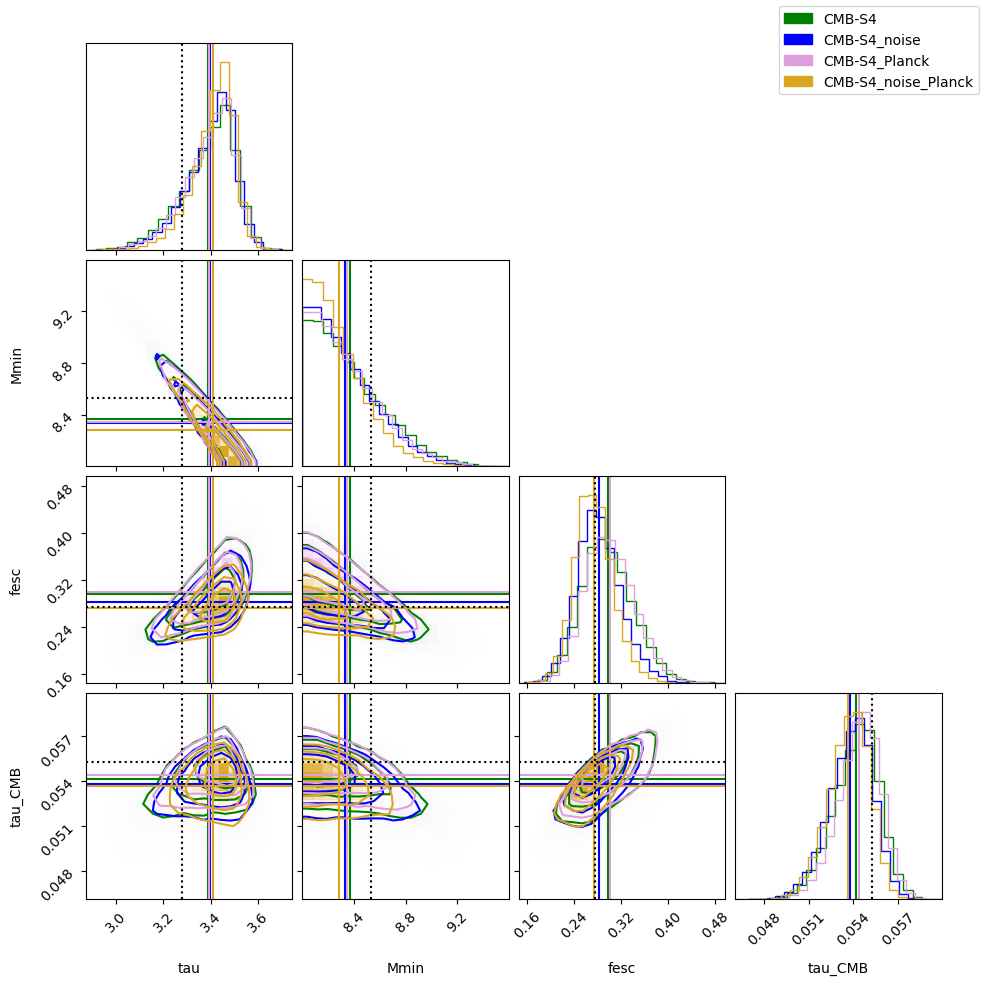

In [53]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_S4):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-S4{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup  has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _noise has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _Planck has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _noise_Planck has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


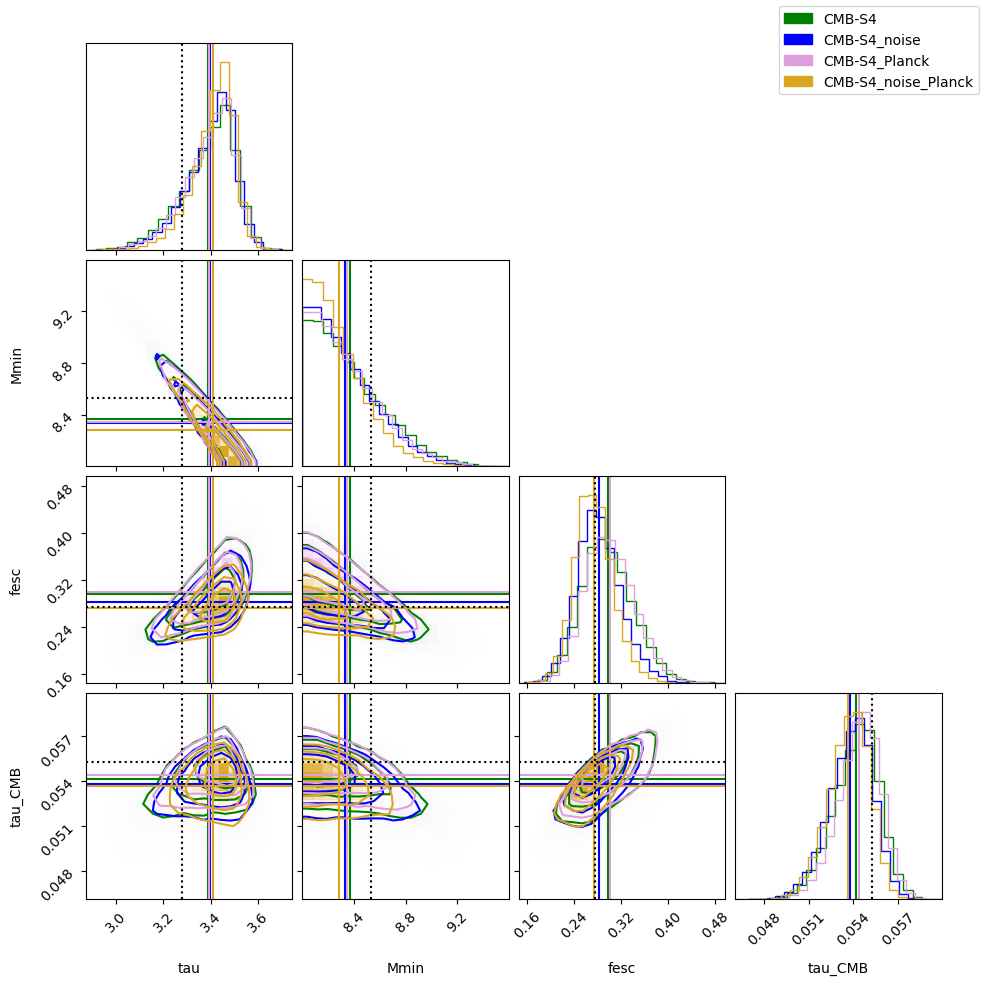

In [69]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_S4):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-S4{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup  has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


Setup _noise has (120000, 4) samples


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


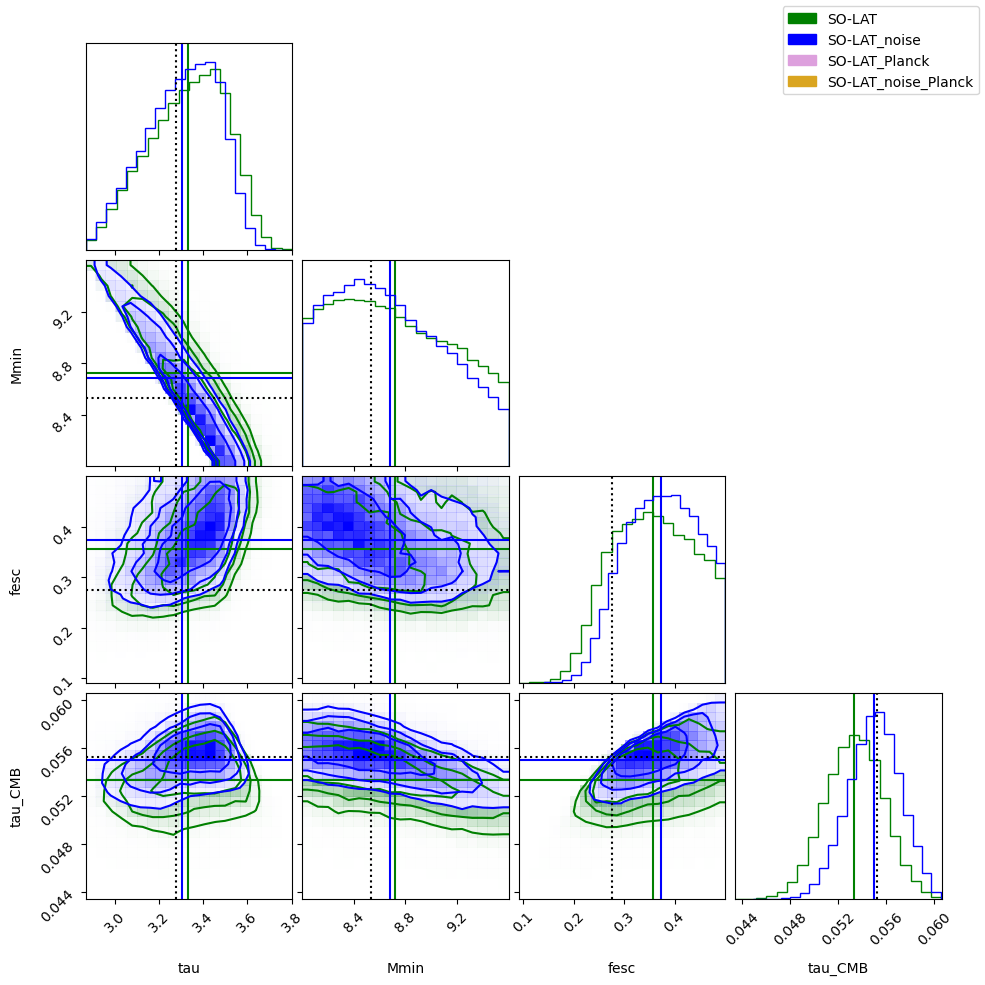

In [54]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_SOLAT):
    if (i == 3) or (i==2):
        continue
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'SO-LAT{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')